# Case 1: Unsupervised Learning in Equity Returns

## Set-up

Imagine you work on an analytics team at an asset-management firm.

The firm trades a diversified portfolio of equities. Beyond forecasting a single stock's return, you are often asked questions like:

- **Risk decomposition:** "What are the main sources of co-movement across our holdings?"
- **Diversification:** "Are we truly diversified, or are many names effectively moving together?"
- **Monitoring:** "If the market regime changes, how would we detect it quickly?"

Unsupervised learning methods are natural tools for these tasks because they help you compress a high-dimensional panel of returns into a small number of summarizing components (e.g., PCA factors) and to discover structure in the cross-section (e.g., clusters of stocks that behave similarly).

In this case you will build a baseline PCA factor model, then use diagnostics and additional unsupervised methods to look for potentially meaningful structure in the data.

### Things to keep in mind

Interpretability is not automatic. PCA components are statistical objects; economic meaning is something you must argue for.

Nonstationarity matters. The latent structure can shift over time (crises, policy changes, sector rotations).

Data leakage matters if you later use these objects for prediction. If you build factors on the full sample and then feed them into a supervised model, you may inadvertently use information from the future.

## Constructing the Return Matrix

In the first problem set, we constructed a return matrix for a cross-section of equities. We follow the same general approach here.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FactorAnalysis
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 500)

In [2]:
#Config

startdate = '2011-01-01' # Change this to your desired start date (Minimum: 2011-01-01)
enddate = '2024-12-31'  # Change this to your desired end date (Maximum: 2024-12-31)

In [3]:
# !wget -O df_factor.csv "https://www.dropbox.com/scl/fi/glm90k03u7yehadyw9dk5/df_factor.csv?rlkey=iwhnsi7sf9ogsvfpm9jltqzew&dl=0"

df = pd.read_csv('df_factor.csv', parse_dates=['date'])
tic_list= df.loc[df['date'] < startdate, 'tic'].unique()
df = df[df['tic'].isin(tic_list[:100])]

df.head()

,Unnamed: 0,date,tic,prcod,prchd,prcld,prccd,vol,ret,cshoc
0,3774,2010-01-04,MSFT,30.62,31.10,30.59,30.950,38564668.0,0.015420,8.879121e+09
1,3775,2010-01-05,MSFT,30.85,31.10,30.64,30.960,49900508.0,0.000323,8.879121e+09
2,3776,2010-01-06,MSFT,30.88,31.08,30.52,30.770,58338993.0,-0.006137,8.879121e+09
3,3777,2010-01-07,MSFT,30.63,30.70,30.19,30.452,50712549.0,-0.010335,8.879121e+09
4,3778,2010-01-08,MSFT,30.28,30.88,30.24,30.660,51358330.0,0.006830,8.879121e+09


In [4]:
df = df[['date', 'tic', 'ret']]
df.head()

,date,tic,ret
0,2010-01-04,MSFT,0.015420
1,2010-01-05,MSFT,0.000323
2,2010-01-06,MSFT,-0.006137
3,2010-01-07,MSFT,-0.010335
4,2010-01-08,MSFT,0.006830


In [5]:
returns_matrix = df.pivot(index='date', columns='tic', values='ret')
returns_matrix = returns_matrix.dropna()

returns_matrix.head()

tic,AAON,AAPL,ADBE,ADI,ADP,AEP,AMAT,AMD,AMGN,APA,AVT,BIIB,BOKF,BPOP,CACC,CAR,CASY,CBSH,CDNS,CGNX,CHDN,CHTR,CINF,COKE,COO,CPB,CRUS,CSCO,CSX,CTAS,EA,EVRG,EXC,FAST,FCNCA,FITB,GEN,GILD,GNTX,HAS,HBAN,HOLX,HON,HST,IDXX,INTC,INTU,IONS,JBHT,KLAC,KMB,LFUS,LIN,LNT,LNW,LPLA,LRCX,LSCC,LSTR,MAT,MCHP,MIDD,MSFT,MTCH,MU,NDSN,NTRS,NWL,ODFL,OLED,ORLY,PARA,PAYX,PCAR,PEP,PTC,QCOM,REG,REGN,RGEN,RGLD,ROP,SBUX,SEIC,SNPS,SWKS,TECH,TER,TRMB,TROW,TTEK,TXN,VRTX,VTRS,WBA,WDC,WEN,XEL,XRAY,ZBRA
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-11-19,-0.001992,-0.005512,0.006276,0.018235,0.002651,-0.008597,-0.009368,0.016327,-0.002539,0.008224,0.000000,0.002007,-0.005877,-0.002622,0.007715,-0.012066,-0.005818,-0.005292,-0.003293,0.000345,0.006851,-0.003351,-0.000332,-0.004804,0.007726,0.000867,0.035206,0.000000,0.011010,0.018423,-0.012227,-0.005556,-0.000500,0.008457,-0.006066,0.014901,0.005251,0.003426,-0.002341,0.012071,-0.006340,-0.003701,0.000804,0.015763,0.001086,0.005710,-0.067842,-0.002060,0.015770,0.005749,-0.004187,0.002036,0.006749,-0.008741,-0.004060,0.013997,0.010428,0.034014,0.005259,-0.000398,0.010128,-0.002890,-0.005709,-0.002545,0.014065,0.006497,0.002351,0.001754,0.017838,0.008368,0.001009,-0.003625,0.007100,0.013288,-0.000926,-0.011050,0.005029,0.006571,-0.012014,0.034301,0.006356,0.011514,0.005886,0.004797,-0.007137,0.013445,-0.005948,0.017153,-0.006999,0.007516,-0.001310,0.014613,-0.019187,0.031169,0.009878,0.051687,0.021505,-0.001695,-0.000966,-0.005365
2010-11-22,0.008383,0.021615,0.011088,0.022172,0.004186,0.006713,0.005466,-0.008032,-0.004727,-0.007057,0.008977,-0.000770,-0.004012,-0.004382,0.017183,-0.002290,0.000000,0.006119,-0.015921,0.008978,0.001570,-0.010647,-0.002988,0.010690,0.025162,0.005195,0.149059,-0.002550,-0.010090,-0.006874,0.003909,0.006784,-0.003000,0.015628,-0.009598,-0.011419,-0.010447,-0.009979,0.008916,-0.011927,0.003321,-0.009907,-0.002611,-0.001862,-0.004803,0.005441,0.013799,-0.009288,-0.006156,0.008982,0.004528,0.005193,-0.005298,0.000551,-0.024457,-0.012270,0.007740,0.002193,-0.013863,0.003187,0.003834,-0.005670,0.001557,0.018222,-0.009337,0.008100,-0.006058,-0.007005,0.005608,0.008299,0.012437,-0.000606,0.004230,-0.007388,-0.000155,0.014432,-0.003128,-0.007979,0.197000,0.005102,0.016381,0.001527,0.003576,-0.003038,0.013179,0.029851,-0.005319,0.056492,-0.004879,-0.007460,-0.000437,0.009393,0.001168,0.014610,0.003740,-0.007946,-0.006316,0.002971,0.005799,-0.002427
2010-11-23,-0.001979,-0.014775,-0.033927,-0.006952,-0.012725,-0.008614,-0.009577,-0.012146,-0.020826,-0.026398,-0.025103,-0.016035,-0.004028,0.003521,0.001003,-0.027544,-0.003308,0.001322,-0.017094,-0.009582,-0.010452,-0.007363,-0.008325,-0.010235,-0.008245,-0.023830,-0.016373,-0.018405,-0.026209,-0.024044,-0.036340,-0.000396,-0.007523,-0.004161,-0.001400,-0.028053,-0.018768,-0.019098,-0.016279,0.000000,-0.029617,0.028143,-0.001007,-0.007463,0.011208,-0.007647,-0.019539,-0.012500,-0.009965,-0.016455,-0.010625,0.023810,-0.009130,-0.007987,-0.038997,0.017391,-0.018349,0.006564,-0.020955,0.003177,-0.008226,-0.005069,-0.023708,-0.000716,0.013523,-0.010170,-0.010224,-0.015873,0.008017,-0.000823,-0.006142,-0.014563,-0.010179,-0.017678,-0.012519,-0.013309,-0.010920,-0.008043,0.015577,0.005051,-0.000777,-0.009702,-0.015225,-0.013931,-0.011431,-0.003221,-0.007019,0.000000,-0.011441,-0.023232,-0.000875,-0.008065,-0.024789,0.000000,-0.026082,-0.022249,-0.006356,-0.011849,-0.011531,0.001081
2010-11-24,0.024990,0.019645,0.007449,0.018482,0.016445,0.009529,0.014102,0.040984,0.004291,0.028252,0.043025,0.023660,0.014900,0.007018,0.024227,0.043273,0.005872,0.007394,0.014907,0.010712,0.025614,-0.001712,0.016454,-0.000345,0.024749,-0.000588,-0.001280,0.013542,0.028410,0.027622,0.008754,0.005551,0.003537,0.025451,0.029113,0.023769,0.028093,0.021633,0.026005,0.007412,0.008977,0.018856,0.016331,0.028822,0.013393,0.014227,0.022168,0.027426,0.014146,0.029073,-0.002766,0.023256,0.016345,0.011938,-0.010145,0.005495,

In [6]:
df.sort_values('date', inplace=True)
print(len(returns_matrix)) # number of rows

3544


## Standardization

Before PCA, we typically standardize each column (ticker) so that PCA focuses on *correlation-style* co-movement rather than simply variance differences driven by a few volatile assets.


In [7]:
returns_standardized = (returns_matrix - returns_matrix.mean()) / returns_matrix.std()  #Z score Standardization

returns_standardized.head()


tic,AAON,AAPL,ADBE,ADI,ADP,AEP,AMAT,AMD,AMGN,APA,AVT,BIIB,BOKF,BPOP,CACC,CAR,CASY,CBSH,CDNS,CGNX,CHDN,CHTR,CINF,COKE,COO,CPB,CRUS,CSCO,CSX,CTAS,EA,EVRG,EXC,FAST,FCNCA,FITB,GEN,GILD,GNTX,HAS,HBAN,HOLX,HON,HST,IDXX,INTC,INTU,IONS,JBHT,KLAC,KMB,LFUS,LIN,LNT,LNW,LPLA,LRCX,LSCC,LSTR,MAT,MCHP,MIDD,MSFT,MTCH,MU,NDSN,NTRS,NWL,ODFL,OLED,ORLY,PARA,PAYX,PCAR,PEP,PTC,QCOM,REG,REGN,RGEN,RGLD,ROP,SBUX,SEIC,SNPS,SWKS,TECH,TER,TRMB,TROW,TTEK,TXN,VRTX,VTRS,WBA,WDC,WEN,XEL,XRAY,ZBRA
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-11-19,-0.141235,-0.375508,0.267198,0.950842,0.138259,-0.739022,-0.447182,0.421623,-0.209073,0.250185,-0.020321,0.058083,-0.329048,-0.147201,0.278003,-0.321746,-0.394355,-0.374123,-0.234326,-0.018273,0.271863,-0.216331,-0.064136,-0.278605,0.418329,0.042297,1.191752,-0.034116,0.596973,1.102939,-0.660404,-0.455146,-0.057702,0.463499,-0.328839,0.659614,0.236805,0.157928,-0.153547,0.617904,-0.337172,-0.249162,0.012583,0.751980,0.011501,0.263563,-3.747032,-0.091379,0.924166,0.200064,-0.395690,0.067652,0.455216,-0.739584,-0.140902,0.573410,0.383489,1.083367,0.297633,-0.028906,0.441472,-0.166459,-0.412420,-0.136038,0.437719,0.317642,0.108098,0.058751,0.878869,0.221368,0.001271,-0.148497,0.455871,0.774352,-0.122620,-0.570823,0.206824,0.345954,-0.565049,1.092036,0.251108,0.766948,0.299009,0.260612,-0.473473,0.494028,-0.371313,0.678146,-0.351790,0.392719,-0.113232,0.815550,-0.728748,1.399345,0.506684,1.898251,0.988495,-0.178960,-0.056495,-0.275147
2010-11-22,0.321819,1.169788,0.508960,1.165189,0.249255,0.504641,0.189574,-0.265297,-0.352197,-0.224348,0.460860,-0.054198,-0.233071,-0.225839,0.663531,-0.087452,-0.048235,0.356100,-0.892854,0.337801,0.021547,-0.599077,-0.226959,0.447957,1.456417,0.353194,5.155698,-0.193434,-0.619920,-0.507526,0.154046,0.472558,-0.230535,0.893250,-0.494971,-0.564027,-0.566551,-0.621222,0.451254,-0.647233,0.129251,-0.612257,-0.227063,-0.108963,-0.310906,0.250404,0.702388,-0.315313,-0.411927,0.342657,0.352800,0.225893,-0.435896,-0.000296,-0.670943,-0.583794,0.272849,0.034191,-0.926540,0.129771,0.148177,-0.295416,0.035360,0.742688,-0.354328,0.405105,-0.368618,-0.293335,0.235887,0.219286,0.716522,-0.034239,0.252284,-0.486521,-0.051902,0.656315,-0.178911,-0.481977,8.346620,0.120421,0.687246,0.060289,0.165280,-0.219862,0.711857,1.132607,-0.335805,2.331169,-0.253889,-0.444276,-0.066584,0.508478,0.004343,0.651902,0.192580,-0.316896,-0.332136,0.198287,0.318766,-0.146301
2010-11-23,-0.140655,-0.903177,-1.752656,-0.420445,-0.973590,-0.740403,-0.456154,-0.381311,-1.405279,-0.824959,-1.365878,-0.671397,-0.233894,0.127272,0.004697,-0.692695,-0.245032,0.049126,-0.954024,-0.427719,-0.548287,-0.426799,-0.554140,-0.533282,-0.532537,-1.731786,-0.604040,-1.184017,-1.549545,-1.600607,-1.877487,-0.067224,-0.543224,-0.292685,-0.109367,-1.337357,-0.992384,-1.151254,-0.902390,-0.018460,-1.460960,1.613937,-0.114503,-0.382560,0.565653,-0.389863,-1.114527,-0.414825,-0.644034,-0.779259,-0.948620,1.159051,-0.719348,-0.679594,-1.048783,0.722934,-0.800995,0.178308,-1.380564,0.129329,-0.413808,-0.267537,-1.521641,-0.058647,0.419375,-0.591742,-0.604794,-0.649802,0.362538,-0.055895,-0.446293,-0.562457,-0.769836,-1.114030,-1.185957,-0.679610,-0.547386,-0.485619,0.611340,0.118724,-0.059212,-0.734251,-0.923140,-0.887864,-0.724004,-0.154670,-0.431772,-0.042622,-0.556919,-1.325759,-0.089988,-0.518508,-0.930506,-0.007567,-1.333521,-0.848200,-0.334034,-0.999914,-0.642544,0.007541
2010-11-24,1.063019,1.057567,0.326131,0.964290,1.135712,0.733390,0.560278,1.116946,0.237697,0.872130,2.285882,0.933564,0.740181,0.283520,0.950356,1.004520,0.301097,0.437691,0.714771,0.409321,1.161216,-0.130349,0.964916,-0.069509,1.431828,-0.062222,-0.078557,0.811956,1.600476,1.688569,0.398593,0.379863,0.221388,1.481932,1.325854,1.071896,1.405759,1.216190,1.369389,0.372289,0.402316,1.070582,1.102184,1.389884,0.685276,0.680216,1.158497,0.822140,0.825205,1.228784,-0.273647,1.131282,1.165028,0.905672,-0.299028,0

---

**Question 1.** Why might standardization make sense when looking at unsupervised learning in a cross-section of equities? E.g., what would happen if one ticker had much higher volatility than the others.

When might you *not* want to standardize before PCA (or applying other unsupervised learning methods)?

If you wanted to use unsupervised learning as part of a supervised learning pipeline that includes train/test splits, what mistake has been made in the above code that does the standardization?


**Answer 1.** Because we care about co-movement much more rather than actual Capital Asset Pricing Model (CAPM) $\beta$ distribution or similarity. That is, we care that stock A & B go up (or down) in price together, regardless of the fact that one of them typically experience much higher returns (or losses) than the other. This is useful for assessing sector/industry clusters, treating all players as equal (regardless of individual stock price volatility). Note that firm size (market cap) and baseline price had always been standardized because we had been using percentage returns instead of dollar.

We _might_ want to keep returns unstandardized (use the raw % value) if we want to understand not only co-movement, but also relative volatility. This might be more useful for portfolio returns modeling.

For supervised learning with training, validation, and testing subsamples, using Z-score standardization is only permissible _after_ the data has been split. That is, we should train our prediction model as if we only have access to the training data and so do the Z-score standardization only with that subset. The validation and testing subsamples will also be transformed before we conduct the validation and testing exercise, but their "standardization" will always be relative to the training data mean and variance.

---

## Baseline PCA

We now look at the first two principal components extracted from PCA applied to the standardized return matrix.

At this stage, the choice of two components is arbitrary. It is not meant to be optimal or economically justified. Instead, this serves as a baseline specification that we will later revisit and improve.

PCA extracts directions in the data that explain the largest share of cross-sectional variance. The resulting components are purely statistical objects. Whether they correspond to economically meaningful forces is something you will need to evaluate.

From the PCA output, we construct two objects:

- The **factor loadings**, which describe how each stock loads on each extracted component.
- The **factor time series**, which describe how the extracted components evolve over time.

In [8]:
pca = PCA(n_components=2) # n_componments = number of factors
factors = pca.fit_transform(returns_standardized)

In [9]:
factor_loadings = pd.DataFrame(pca.components_.T,
                               index=returns_standardized.columns,
                               columns=["Factor1", "Factor2"])

factors_df = pd.DataFrame(factors, index=returns_standardized.index,
                          columns=["Factor1", "Factor2"])

factor_loadings.head()

,Factor1,Factor2
tic,,
AAON,0.093359,0.015169
AAPL,0.102197,-0.079168
ADBE,0.106072,-0.097897
ADI,0.125779,-0.140363
ADP,0.123532,0.073602


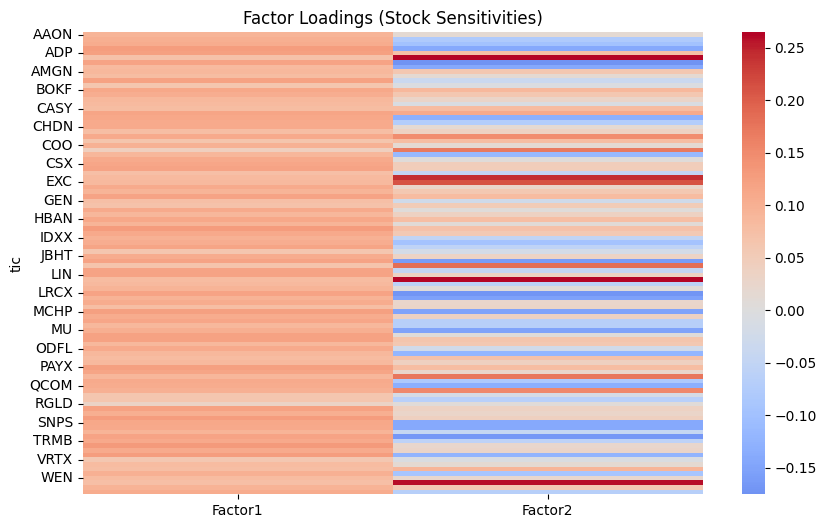

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(factor_loadings, annot=False, cmap="coolwarm", center=0)
plt.title("Factor Loadings (Stock Sensitivities)")
plt.show()

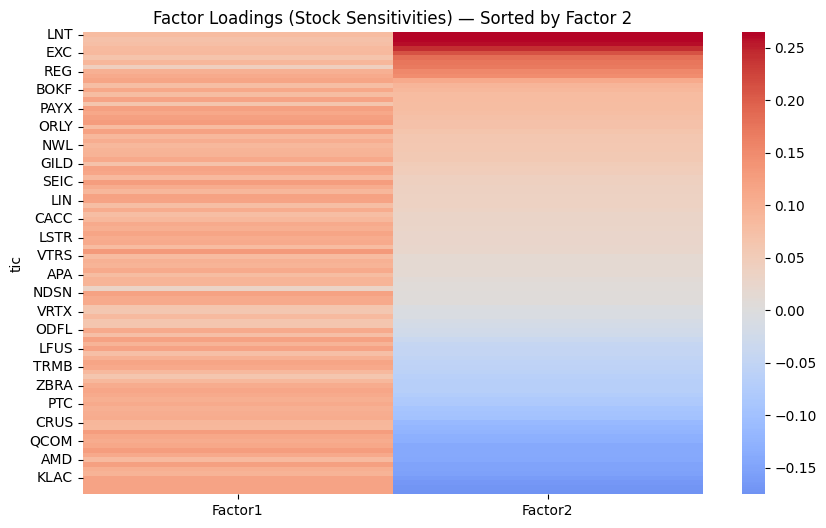

In [44]:
factor_loadings_sorted = factor_loadings.sort_values("Factor2", ascending=False)

plt.figure(figsize=(10,6))
# plt.figure(figsize=(10,25)) # to see all ticker labels
sns.heatmap(factor_loadings_sorted, annot=False, cmap="coolwarm", center=0)
plt.title("Factor Loadings (Stock Sensitivities) — Sorted by Factor 2")
plt.show()

---

**Question 2.** The code block above produces a heatmap showing the factor loadings. Examine the heatmap of factor loadings carefully. Do the exposures suggest an economic story (e.g., a market-wide factor, growth vs value, tech vs non. tech)? What additional data would you want to validate your story (e.g., sector labels, fundamentals, ...)?


**First, a little blurb on what's going on:** The code block runs PCA, finding $k$ (an input parameter; in this case $k = 2$) dimensions that best capture the co-movement structure across all tickers simultaneously. How is it done?

- The setup: The data we have, now in the form of the `returns_standardized` data frame, has `3544` rows (observations, each representing each day). Each row has values across 100 columns that represents stock returns on the day, one for a ticker (e.g., AAPL, Apple Inc.). This means each data point can be mapped as a coordinate in a 100-dimensional space, each direction (axis) for each ticker. From this populated 100-dimensional space, one can construct a 100×100 correlation matrix (a representation of how each axis' value are tied to other axes).

- The main process: PCA operates on this 100×100 correlation matrix, trying to construct a _new_ dimension (a new axis cutting through the original 100-dimensional space). I visualize this new axis as a straight line that crosses through the 100-dimensional space. The direction of that line—the linear function that forms the line—is chosen through an algorithm that maximizes the variance of the 3544 existing observation on that axis.

- For a $k = 2$ factor PCA, this is followed by the second axis, which captures the next most shared variance, constrained to be orthogonal ($90$ degrees) to the first. We can then ignore the original 100 axes. For a higher-dimensional PCA, the process continues, each new axis orthogonal to all the previous ones.

The output is then visualized as a heatmap, with colors representing the ticker's coordinate (factor loading) along the two selected axes.

In [12]:
factor_loadings_sorted.describe()

,Factor1,Factor2
count,100.000000,100.000000
mean,0.097985,0.006036
std,0.020072,0.100321
min,0.032578,-0.175090
25%,0.084032,-0.064508
50%,0.102361,0.015467
75%,0.113300,0.058571
max,0.131922,0.264607


In [13]:
import yfinance as yf

spy = yf.download('SPY', start=startdate, end=enddate)['Close'].pct_change().dropna()
spy.name = 'market'

betas = {}
for tic in returns_matrix.columns:
    aligned = pd.concat([returns_matrix[tic], spy], axis=1, sort=False).dropna()
    cov = np.cov(aligned.iloc[:, 0], aligned.iloc[:, 1])
    betas[tic] = cov[0, 1] / cov[1, 1]

[*********************100%***********************]  1 of 1 completed


In [14]:
beta_df = pd.Series(betas, name='beta').to_frame()
factor_loadings_with_beta = factor_loadings.join(beta_df)
factor_loadings_with_beta = factor_loadings_with_beta.dropna()
factor_loadings_with_beta.head()

,Factor1,Factor2,beta
tic,,,
AAON,0.093359,0.015169,1.106930
AAPL,0.102197,-0.079168,1.121935
ADBE,0.106072,-0.097897,1.264267
ADI,0.125779,-0.140363,1.241262
ADP,0.123532,0.073602,0.971291


In [15]:
factor_correlation = factor_loadings_with_beta[['Factor1', 'Factor2', 'beta']].corr()
factor_correlation

,Factor1,Factor2,beta
Factor1,1.000000,-0.296664,0.489307
Factor2,-0.296664,1.000000,-0.727446
beta,0.489307,-0.727446,1.000000


**Answer 2.**

The heatmap shows two factors. Factor 1, has value (loading) range of `[0.033, 0.132]`. The range is narrow and uniformly positive across all tickers. This is very likely a general market factor that affects all stocks in the same direction with roughly equal intensity. 

Our working hypothesis is that the primary factor influencing co-movement is the generally positive long-term macroeconomic growth and inflation, and values along the Factor 1 axis correspond to how affected the ticker movement is by that influence. In a way, it captures the same thing as $\beta$, though only after standardizing the returns, and is specific to this sample of tickers.

Factor 2, with a range of `[-0.175, 0.265]` and a mean of `0.006`, captures co-movement that cannot be explained by Factor 1 (whatever it actually was). That is, two imaginary tickers with identical Factor 1 loadings and similar Factor 2 loadings would tend to move together; two with identical Factor 1 loadings but very different Factor 2 loadings, they tend to not move together; two with opposite Factor 2 loadings (e.g., `-1` and `1`), they would move in opposite directions. 

One interpretation is Factor 2 captures—to a certain extent—a growth/cyclical vs. defensive dimension, controlling for the same (or similar) $\beta$ value.

To validate the hypothesis, I would get:
- Sector labels (GICS) to check whether Factor 2 loadings cluster by sector. We would expect a small intra-cluster spread/variance of Factor 2 loading, and a big difference between clusters.
- 10-year Treasury yield changes (FRED: `DGS10`) to regress Factor 2 time series on yield changes; if the hypothesis is right, Factor 2 should be negative when yields rise

---

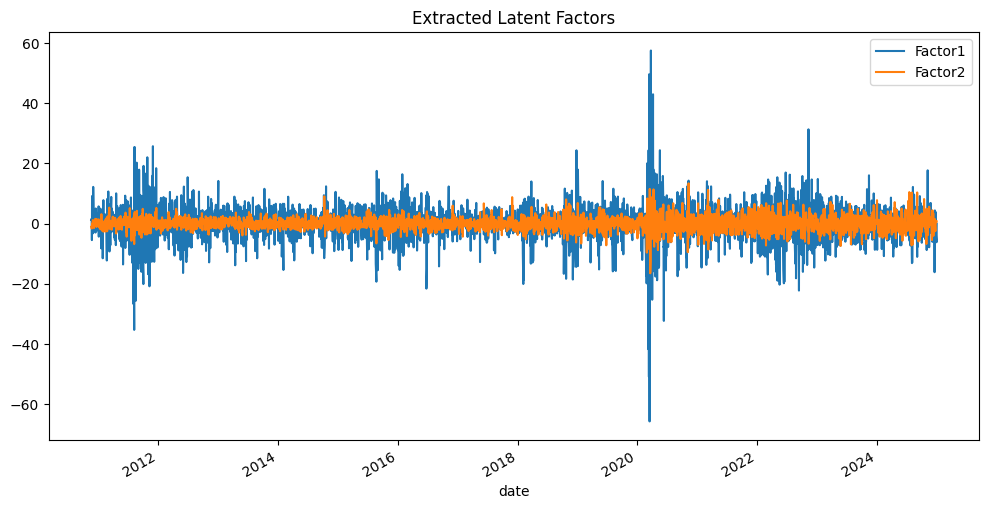

In [16]:
factors_df.plot(figsize=(12,6), title="Extracted Latent Factors")
plt.show()

---

**Question 3.** Now we present the time-series plots of the two extracted components. Consider their volatility, persistence, and behavior during turbulent periods. Do the factors move together, or do they appear to capture distinct sources of variation?

In [17]:
factors_df.describe()

,Factor1,Factor2
count,3.544000e+03,3.544000e+03
mean,5.613769e-17,4.410818e-17
std,6.128893e+00,2.247362e+00
min,-6.590291e+01,-1.656894e+01
25%,-2.807702e+00,-1.208801e+00
50%,1.413041e-01,-2.714338e-02
75%,3.046282e+00,1.164256e+00
max,5.761753e+01,1.339407e+01


In [18]:
factors_time_series_correlation = factors_df[['Factor1', 'Factor2']].corr()
factors_time_series_correlation

,Factor1,Factor2
Factor1,1.000000e+00,-2.984623e-17
Factor2,-2.984623e-17,1.000000e+00


**Answer 3.** The time series shows that Factor 1 is much more dominant compared to Factor 2 in driving stock price co-movement. But Factor 2, for the most part, is independent of Factor 1. They don't move together, nor do they move in opposite direction. This suggests that they do in fact capture distinct source of variation.

---

## Exploring Factor Behavior at a More Granular Level

The next two cells allow you to inspect the extracted factors more closely.

First, you can isolate a specific year and examine how the latent factors behave within that shorter window. This can be useful for identifying regime changes, crisis dynamics, or shifts in factor dominance that may not be obvious in the full-sample plot.

Second, you can overlay the return of a specific asset on top of one or more extracted factors. This provides a more detailed view of how individual securities co-move with the latent components. While this is not a formal regression, it can help build intuition about explanatory power and exposure patterns.

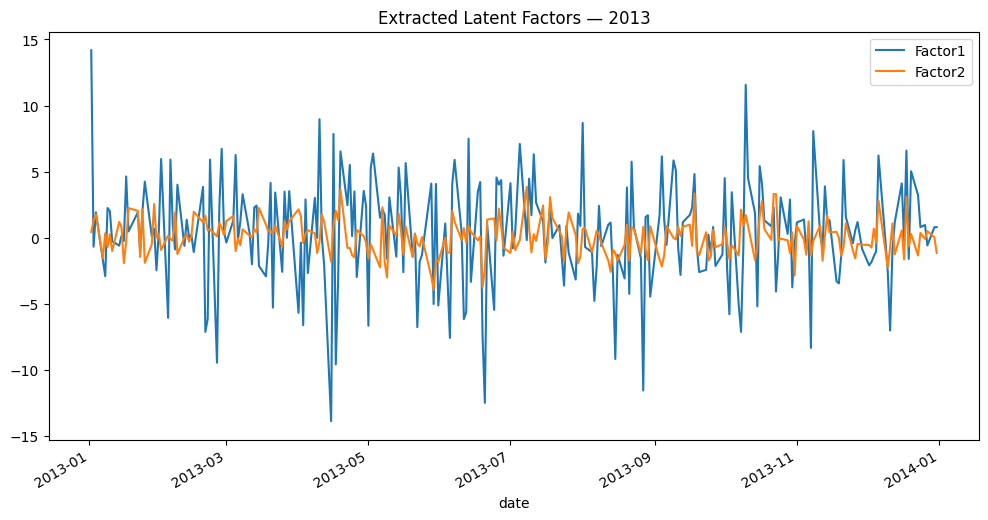

In [19]:
year = 2013 # Change this to the year you want to visualize

factors_df[factors_df.index.year == year].plot(
    figsize=(12,6),
    title=f"Extracted Latent Factors — {year}"
)

plt.show()

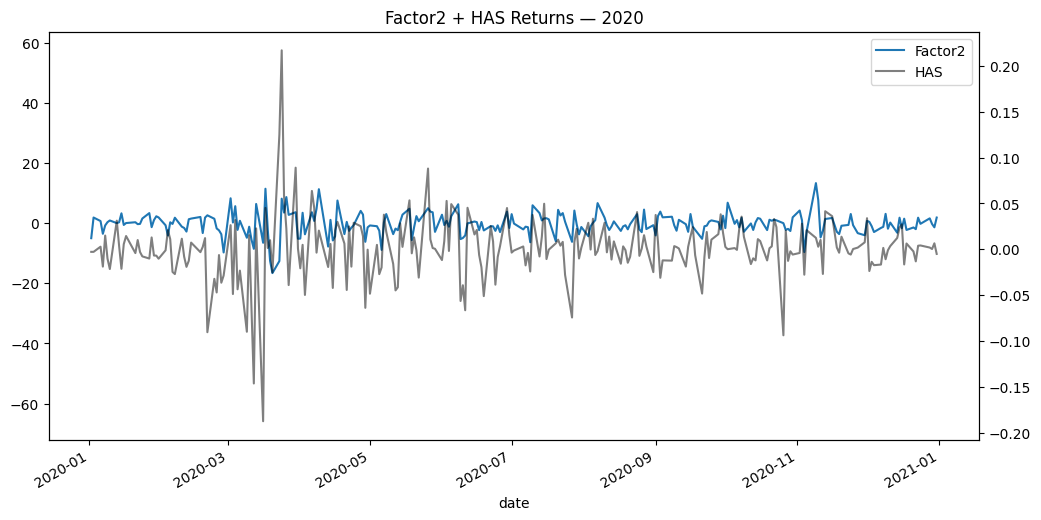

In [20]:
year = 2020 # Change this to the year you want to visualize
asset = "HAS" # Change this to the asset you want to visualize
factor_choice = "Factor2"   # "Factor1" / "Factor2" / "All"

ymin = factors_df.loc[str(year)].min().min()
ymax = factors_df.loc[str(year)].max().max()
padding = 0.05 * (ymax - ymin)

cols = factors_df.columns if factor_choice == "All" else [factor_choice]

ax = factors_df.loc[str(year), cols].plot(
    figsize=(12,6),
    title=f"{factor_choice} + {asset} Returns — {year}"
)

ax.set_ylim(ymin - padding, ymax + padding)

returns_matrix.loc[str(year), asset].plot(
    ax=ax,
    secondary_y=True,
    label=asset,
    color="black",
    alpha=0.5,
    mark_right=False
)

ax.legend(ax.get_legend_handles_labels()[0] + ax.right_ax.get_legend_handles_labels()[0],
          ax.get_legend_handles_labels()[1] + ax.right_ax.get_legend_handles_labels()[1])

plt.show()


---

**Question 4.** Use these visualizations thoughtfully. Vary the year, the asset, and the selected factor(s).

- Does the relationship between an asset and a factor appear stable across time?
- Does one factor seem to matter more for certain assets?
- Are there periods where the factors fail to track asset behavior?

**Answer 4.**

- Relationship between Factor 1 and asset returns seems to be stable, but the same does not apply as much to Factor 2. 
- Factor 1 seems to matter more for most assets.
- In periods of global market shock (e.g., March–April 2020, when COVID-19 became headline news), Factor 2 does not track asset behavior whatsoever. Factor 1 absolutely dominated.

---

## Clustering: do groups of stocks behave similarly?

PCA compresses the panel into a few dimensions. We can then cluster stocks based on their factor loadings.

One simple approach:

- represent each ticker by its loadings on the first `N_FACTORS` components,
- apply a clustering algorithm (e.g., k-means),
- see whether clusters look “sensible” (potentially corresponding to industries, styles, or risk exposures).

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Build the feature matrix for clustering: each ticker is represented by its loadings
X_cluster = factor_loadings.values

# Arbitrarily choose K = 4
K = 4

km = KMeans(n_clusters=K, random_state=0, n_init=50)
cluster_labels = km.fit_predict(X_cluster)

clusters = pd.Series(cluster_labels, index=factor_loadings.index, name='cluster')
print(clusters.value_counts().sort_index())

# Show a few tickers per cluster
for k in range(K):
    members = clusters[clusters == k].index.tolist()
    print(f"\nCluster {k}: n = {len(members)}")
    print(members[:20])


cluster
0    10
1    22
2    49
3    19
Name: count, dtype: int64

Cluster 0: n = 10
['AEP', 'CINF', 'CPB', 'EVRG', 'EXC', 'KMB', 'LNT', 'PEP', 'REG', 'XEL']

Cluster 1: n = 22
['AAPL', 'AVT', 'BIIB', 'CAR', 'CGNX', 'EA', 'GEN', 'IDXX', 'INTU', 'IONS', 'LFUS', 'LNW', 'MSFT', 'MTCH', 'ODFL', 'PTC', 'REGN', 'RGEN', 'TECH', 'TRMB']

Cluster 2: n = 49
['AAON', 'ADP', 'AMGN', 'APA', 'BOKF', 'BPOP', 'CACC', 'CASY', 'CBSH', 'CHDN', 'CHTR', 'COKE', 'COO', 'CSCO', 'CSX', 'CTAS', 'FAST', 'FCNCA', 'FITB', 'GILD']

Cluster 3: n = 19
['ADBE', 'ADI', 'AMAT', 'AMD', 'CDNS', 'CRUS', 'INTC', 'KLAC', 'LRCX', 'LSCC', 'MCHP', 'MU', 'OLED', 'QCOM', 'SNPS', 'SWKS', 'TER', 'TXN', 'WDC']


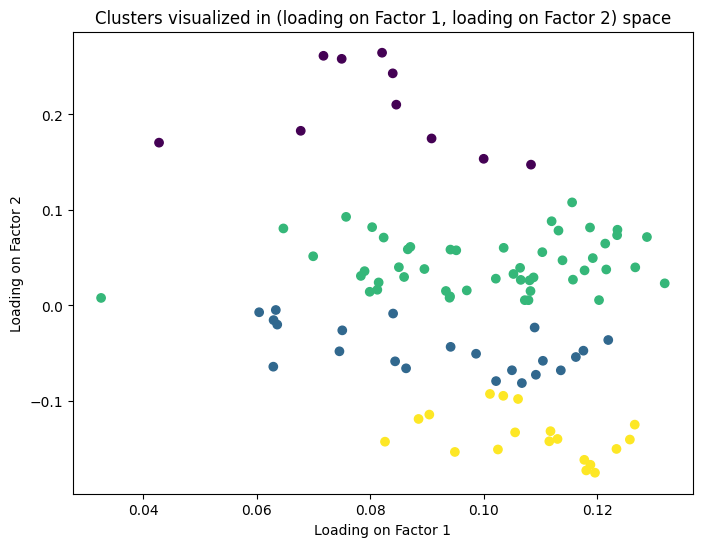

In [22]:
# 2D scatter of loadings on the two factors
plt.figure(figsize=(8,6))
plt.scatter(factor_loadings.iloc[:,0], factor_loadings.iloc[:,1], c=cluster_labels)
plt.title('Clusters visualized in (loading on Factor 1, loading on Factor 2) space')
plt.xlabel('Loading on Factor 1')
plt.ylabel('Loading on Factor 2')
plt.show()


---

**Question 5.** Pick **one** cluster and investigate it: do the tickers look like they come from similar industries? (You can use the web, Bloomberg/Yahoo, or AI tools to quickly look up what the tickers are.)

How would you validate whether the clusters are truly “industry clusters” vs “style/risk clusters” vs something more idiosyncratic?

In [23]:
sector_data = {}
for tic in factor_loadings.index:
    try:
        info = yf.Ticker(tic).info
        sector_data[tic] = {
            'sector': info.get('sector', None),
            'industry': info.get('industry', None)
        }
    except:
        sector_data[tic] = {'sector': None, 'industry': None}

sector_df = pd.DataFrame(sector_data).T
cluster_sector = sector_df.join(clusters)

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


In [45]:
cluster_sector.head()
cluster_sector[cluster_sector['sector'] == 'Industrials'].sort_values('cluster')

,tic,cluster,sector,industry
0,AAON,1,Industrials,Building Products & Equipment
14,CAR,1,Industrials,Rental & Leasing Services
27,CSX,1,Industrials,Railroads
28,CTAS,1,Industrials,Specialty Business Services
32,FAST,1,Industrials,Industrial Distribution
41,HON,1,Industrials,Conglomerates
46,JBHT,1,Industrials,Integrated Freight & Logistics
55,LSTR,1,Industrials,Integrated Freight & Logistics
58,MIDD,1,Industrials,Specialty Industrial Machinery
62,NDSN,1,Industrials,Specialty Industrial Machinery


In [25]:
pd.crosstab(cluster_sector['cluster'], cluster_sector['sector'])

sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
cluster,,,,,,,,,,,
0,0,0,0,3,0,1,0,0,1,0,5
1,0,2,0,0,0,0,7,2,0,10,0
2,2,1,8,2,1,11,6,11,1,4,0
3,0,0,0,0,0,0,0,0,0,19,0


In [26]:
pd.crosstab(cluster_sector['cluster'], cluster_sector['industry'])

industry,Asset Management,Auto Parts,Banks - Regional,Beverages - Non-Alcoholic,Biotechnology,Building Products & Equipment,Capital Markets,Communication Equipment,Computer Hardware,Conglomerates,Consumer Electronics,Credit Services,Diagnostics & Research,Drug Manufacturers - General,Drug Manufacturers - Specialty & Generic,Electronic Components,Electronic Gaming & Multimedia,Electronics & Computer Distribution,Engineering & Construction,Farm & Heavy Construction Machinery,Gambling,Gold,Household & Personal Products,Industrial Distribution,Insurance - Property & Casualty,Integrated Freight & Logistics,Internet Content & Information,Leisure,Medical Instruments & Supplies,Oil & Gas E&P,Packaged Foods,REIT - Hotel & Motel,REIT - Retail,Railroads,Rental & Leasing Services,Restaurants,Scientific & Technical Instruments,Semiconductor Equipment & Materials,Semiconductors,Software - Application,Software - Infrastructure,Specialty Business Services,Specialty Chemicals,Specialty Industrial Machinery,Specialty Retail,Telecom Services,Trucking,Utilities - Regulated Electric
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,4,0,0,1,0,0,1,0,1,1,0,1,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,2,0,0,2,2,0,0,0,0,0,1,0
2,3,2,6,1,0,1,1,1,0,1,0,1,0,2,1,0,0,0,1,1,1,1,1,1,0,2,0,2,3,1,0,1,0,1,0,2,0,0,0,3,0,1,1,2,1,1,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,10,2,1,0,0,0,0,0,0,0


In [27]:
industry_cluster_counts = (
    cluster_sector
    .groupby('industry')['cluster']
    .nunique()
    .rename('n_clusters')
)

total_industries     = len(industry_cluster_counts)
exclusive_industries = (industry_cluster_counts == 1).sum()
split_industries     = (industry_cluster_counts > 1).sum()

print(f"Total distinct industries : {total_industries}")
print(f"Exclusively in 1 cluster  : {exclusive_industries}  ({exclusive_industries/total_industries:.1%})")
print(f"Split across >1 cluster   : {split_industries}  ({split_industries/total_industries:.1%})")

print("\nSplit industries:")
split = cluster_sector[cluster_sector['industry'].isin(
    industry_cluster_counts[industry_cluster_counts > 1].index
)]
print(split.groupby('industry')['cluster'].apply(lambda x: sorted(x.unique())).to_string())

Total distinct industries : 48
Exclusively in 1 cluster  : 40  (83.3%)
Split across >1 cluster   : 8  (16.7%)

Split industries:
industry
Beverages - Non-Alcoholic            [0, 2]
Communication Equipment              [1, 2]
Drug Manufacturers - General         [1, 2]
Electronic Components                [1, 3]
Household & Personal Products        [0, 2]
Medical Instruments & Supplies       [1, 2]
Software - Application            [1, 2, 3]
Software - Infrastructure            [1, 3]


**Answer 5.** The clustering does capture some sector/industry classification, albeit in a non-mutually exclusive way. Out of the 48 represented industries, 40 of them are exclusively in one cluster. For example, Utilites are completely placed in Cluster 0. However, the relationship is only one-way. One cluster can and often do contain multiple industries and sectors. Additionally, the 8 exceptions (industries featured in multiple clusters) do exist.

---

## Main Question

Up to this point, you have constructed a simple two-factor PCA model and explored its loadings and time-series behavior. The number of factors was chosen arbitrarily, and no justification has been provided for why two factors should adequately describe the cross-section of returns (or why subsequently clustered into four groups).

Your task now is to continue trying to find interesting structure by exploring the data using unsupervised learning.

There is no single correct answer. A strong solution will:

- use diagnostics to justify key design choices (number of factors, number of clusters, etc.),
- explore at least **two** unsupervised approaches (PCA + one other, or PCA + clustering variants),
- discuss stability over time (do conclusions depend on the window?), and
- connect results to a business use-case (risk, diversification, monitoring, factor tilts, etc.).

---

**Question 6.** Starting from the baseline PCA workflow above:

1. Decide on a sensible number of PCA factors and justify your choice.
2. Use PCA outputs to explore cross-sectional structure. Then go beyond PCA using at least **one** additional unsupervised method (examples: clustering on loadings, clustering on correlations, hierarchical clustering, anomaly detection, etc.).
3. Provide evidence about whether the structure you find is stable (e.g., compare pre- and post-2020, or run PCA/clustering on subperiods).

Be explicit about:

- what your unsupervised method is optimizing,
- what “success” means in your context,
- and what you would want to validate using additional data sources.

---

**Question 7.** Finally (and most importantly), prepare a slide deck suitable for a 10 minute presentation to a portfolio manager or risk committee. Your presentation should include, at a minimum, 1. The business objective: why we are doing unsupervised learning here? 2. The main structure you found (factors, clusters, regimes) and how you diagnosed it. 3. How a manager could *use* these outputs operationally (risk monitoring, diversification checks, factor-aware allocation, stress testing, etc.). 4. What could go wrong (nonstationarity/regime changes, over-interpretation of PCA, sensitivity to sample window, and data leakage risks if used for prediction).


In [28]:
# ── Load and pivot ──────────────────────────────────────────────────────────
df = pd.read_csv('df_factor.csv', parse_dates=['date'])
startdate = '2011-01-01'
enddate   = '2024-12-31'

tic_list = df.loc[df['date'] < startdate, 'tic'].unique()
df = df[df['tic'].isin(tic_list[:100])]
df = df[(df['date'] >= startdate) & (df['date'] <= enddate)]

# Pivot: rows = dates, columns = tickers
ret_wide = df.pivot(index='date', columns='tic', values='ret').dropna(axis=1)

# ── Train/test split on RAW data (time-based, no shuffling) ─────────────────
split_date = '2020-12-31'          # ~10 yr train, ~4 yr test
ret_train = ret_wide.loc[ret_wide.index <= split_date]
ret_test  = ret_wide.loc[ret_wide.index >  split_date]

print(f"Train: {ret_train.index[0].date()} → {ret_train.index[-1].date()}  ({len(ret_train)} days)")
print(f"Test:  {ret_test.index[0].date()}  → {ret_test.index[-1].date()}   ({len(ret_test)} days)")
print(f"Stocks: {ret_train.shape[1]}")

Train: 2011-01-03 → 2020-12-31  (2517 days)
Test:  2021-01-04  → 2024-12-31   (1005 days)
Stocks: 94


In [29]:
# ── Standardize AFTER split: fit only on train ───────────────────────────────
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(ret_train)   # (T_train, N_stocks)
X_test  = scaler.transform(ret_test)        # uses train mean/std — no leakage

# PCA is fit on training observations (rows = days, cols = stocks).
# Loadings (components_) are N_stocks × K, which is what we cluster on.

We want to use intra-cluster variance to measure how similar stocks within the same cluster are. Low intra-cluster variance ⟹ stocks in a cluster move together ⟹ they are not diversifying each other. Inter-cluster variance measures how different clusters are from one another. High inter-cluster variance ⟹ clusters represent genuinely distinct risk exposures. 

A portfolio is well-diversified when you hold stocks across clusters with high inter-cluster distance and low intra-cluster distance — i.e., when the ratio inter/intra is large, which is exactly what a high silhouette score measures at the stock level.

Caveats: These are geometric proxies in loading-space, not direct measures of portfolio variance. A portfolio's realized variance also depends on position weights and tail dependence, neither of which silhouette score captures. Still, if clustering in PCA loading space produces high silhouette scores, it is evidence that the clusters correspond to distinct factor exposures — and holding one name per cluster is a reasonable diversification heuristic.

Conclusion: Silhouette score is a reasonable but imperfect proxy. Intra/inter variance ratio (equivalently, the CH index or silhouette) is the right direction; portfolio variance under equal weights is the stricter financial criterion you'd use in production.

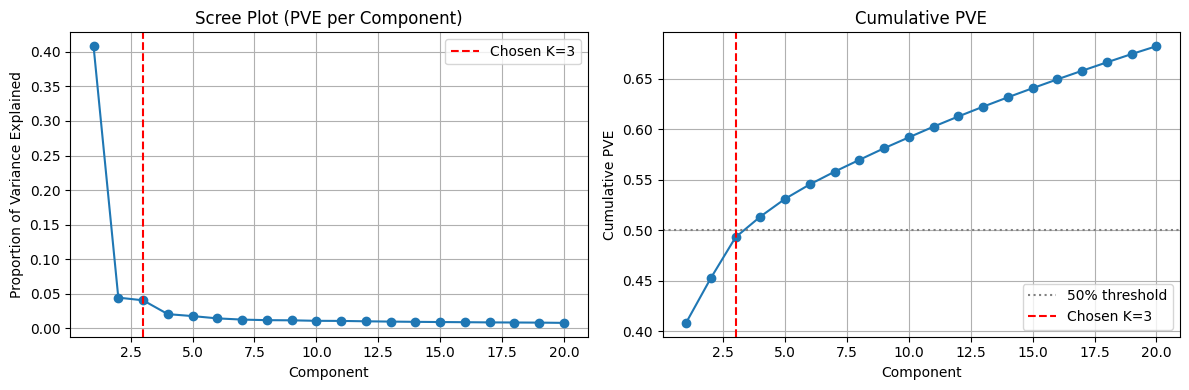

PC1: 0.408  cumulative: 0.408
PC2: 0.044  cumulative: 0.453
PC3: 0.040  cumulative: 0.493
PC4: 0.020  cumulative: 0.514
PC5: 0.018  cumulative: 0.531
PC6: 0.014  cumulative: 0.546
PC7: 0.013  cumulative: 0.558
PC8: 0.012  cumulative: 0.570
PC9: 0.012  cumulative: 0.581
PC10: 0.011  cumulative: 0.592


In [30]:
# ── Fit PCA on train (full rank, then inspect) ───────────────────────────────
N = X_train.shape[1]
pca_full = PCA(n_components=min(N, len(ret_train) - 1))
pca_full.fit(X_train)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree (individual PVE)
axes[0].plot(range(1, 21), explained[:20], marker='o')
axes[0].axvline(x=3, color='red', linestyle='--', label='Chosen K=3')
axes[0].set_title('Scree Plot (PVE per Component)')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].legend()
axes[0].grid(True)

# Cumulative PVE
axes[1].plot(range(1, 21), cumulative[:20], marker='o')
axes[1].axhline(y=0.50, color='gray', linestyle=':', label='50% threshold')
axes[1].axvline(x=3, color='red', linestyle='--', label='Chosen K=3')
axes[1].set_title('Cumulative PVE')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Cumulative PVE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

for i in range(10):
    print(f"PC{i+1}: {explained[i]:.3f}  cumulative: {cumulative[i]:.3f}")

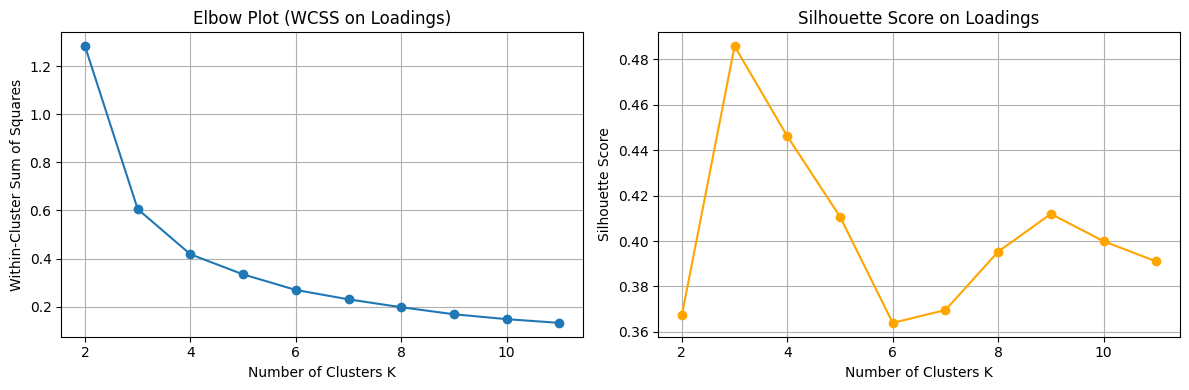

In [31]:
# ── Fit final PCA with chosen K ──────────────────────────────────────────────
K_PCA = 3
pca = PCA(n_components=K_PCA)
pca.fit(X_train)

# Loadings matrix: shape (N_stocks, K_PCA)
# pca.components_ is (K_PCA, N_stocks); transpose to get (N_stocks, K_PCA)
loadings = pca.components_.T  # each row = one stock's exposure to each PC
tickers  = ret_train.columns.tolist()

loadings_df = pd.DataFrame(loadings, index=tickers,
                            columns=[f'PC{i+1}' for i in range(K_PCA)])

# ── K-Means elbow + silhouette on loadings ───────────────────────────────────
K_range = range(2, 12)
wcss       = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(loadings_df.values)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(loadings_df.values, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), wcss, marker='o')
axes[0].set_title('Elbow Plot (WCSS on Loadings)')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].grid(True)

axes[1].plot(list(K_range), sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score on Loadings')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [32]:
print(wcss)
print(sil_scores)

[1.2825880012641246, 0.6055945361558677, 0.41796898045828523, 0.3344559108938133, 0.26981415900714045, 0.23078696604912374, 0.19802027815629053, 0.16885392225875076, 0.14850682503035698, 0.13302547168934803]
[0.3673736340589493, 0.4858252724325864, 0.44615622619201206, 0.41075099052463315, 0.3639507569904167, 0.36961010602640537, 0.3953272493542667, 0.4119311565065028, 0.39992699183956826, 0.3909996249021412]


In [33]:
# ── Choose K_CLUST based on elbow/silhouette, then fit final model ───────────
K_CLUST = 3

km_final = KMeans(n_clusters=K_CLUST, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(loadings_df.values)
loadings_df['cluster'] = cluster_labels

print("Cluster sizes:")
print(loadings_df['cluster'].value_counts().sort_index())
print(f"\nFinal silhouette: {silhouette_score(loadings_df[[f'PC{i+1}' for i in range(K_PCA)]].values, cluster_labels):.3f}")

Cluster sizes:
cluster
0    38
1    48
2     8
Name: count, dtype: int64

Final silhouette: 0.486


/var/folders/rl/zrl2smrn3s92x6d5d2tvgr240000gn/T/ipykernel_9284/607483277.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


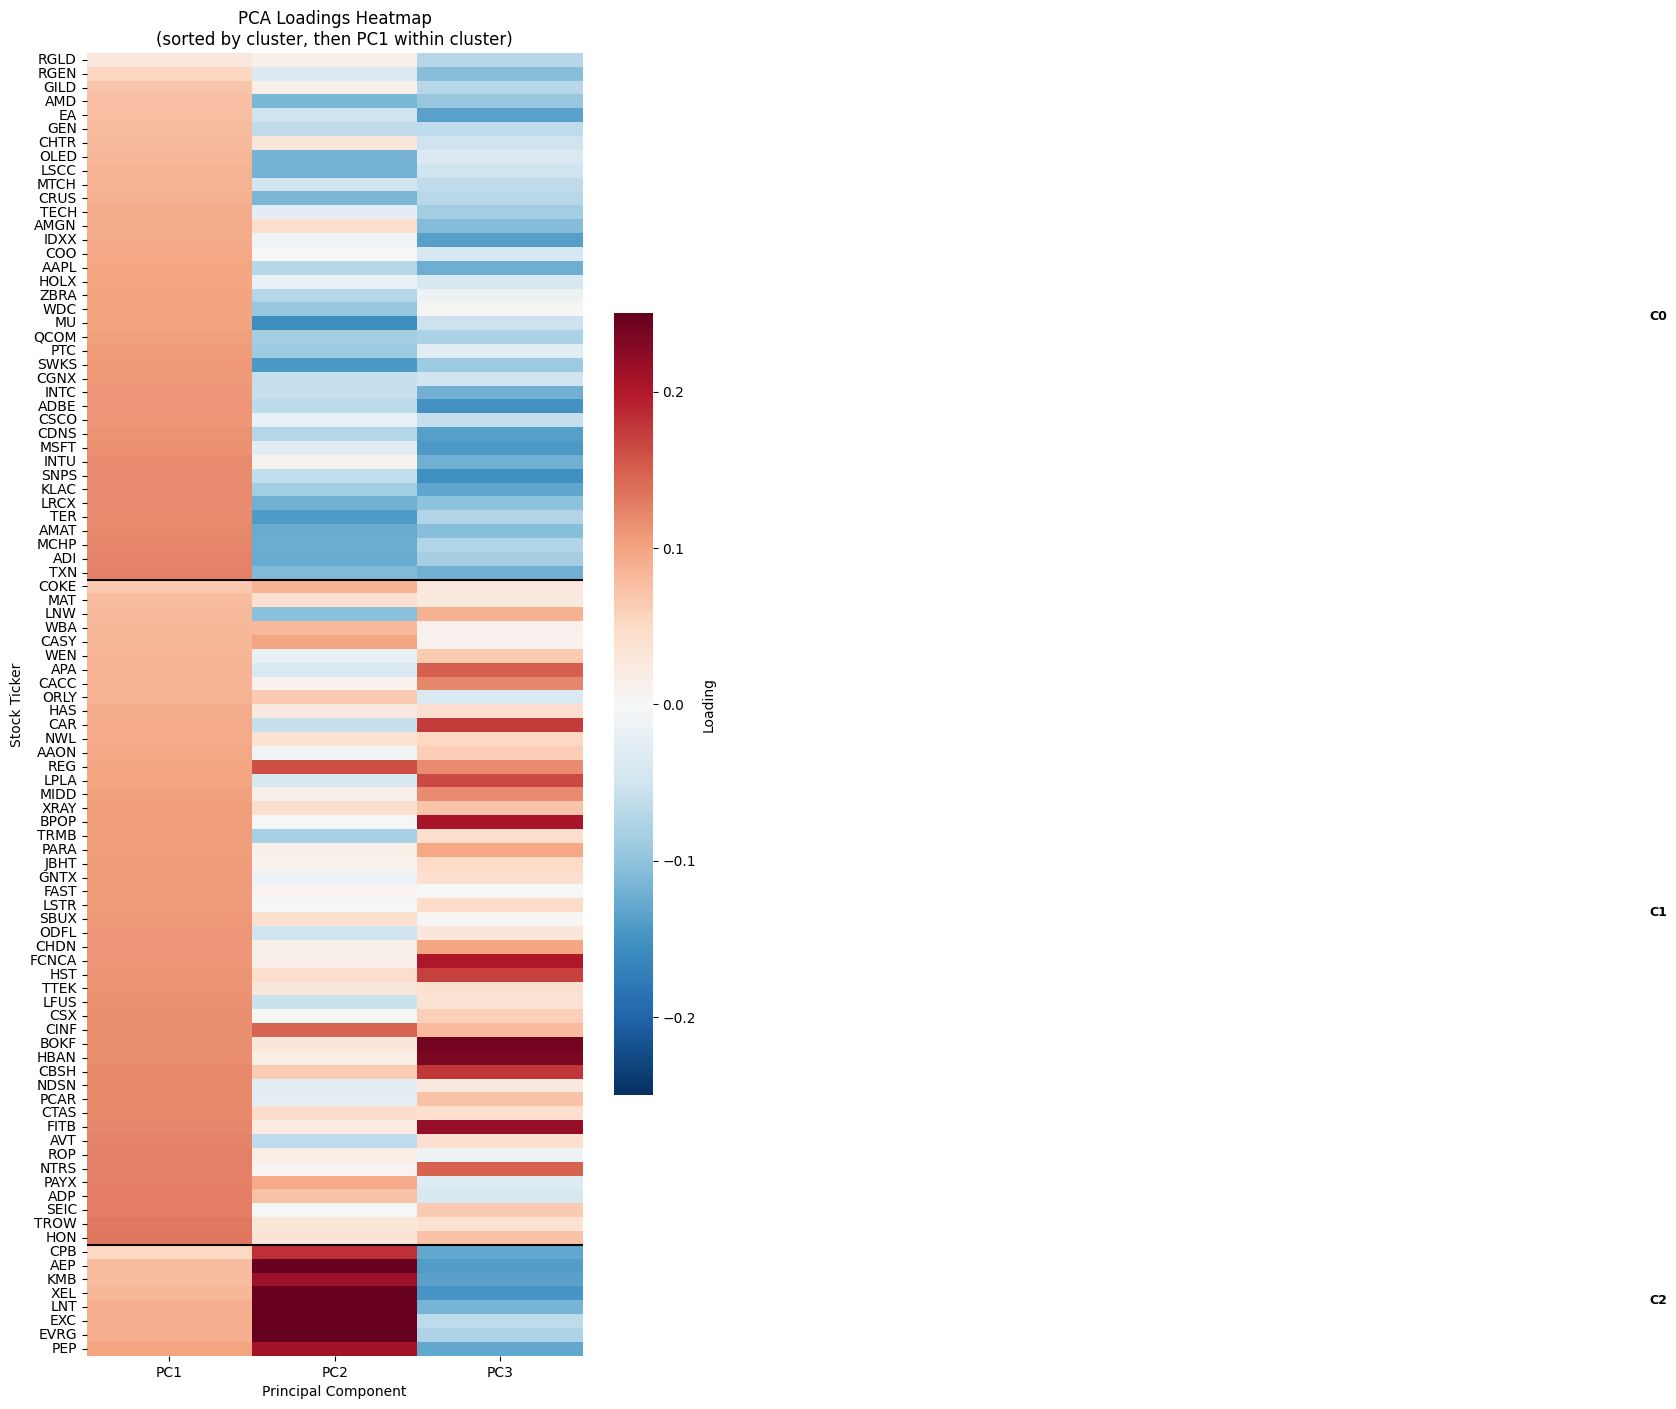

In [34]:
# ── Sort: first by cluster, then by PC1 within cluster ───────────────────────
sort_cols = ['cluster', 'PC1']
loadings_sorted = loadings_df.sort_values(sort_cols)

heatmap_data = loadings_sorted[[f'PC{i+1}' for i in range(K_PCA)]]

# Cluster boundary positions for visual separators
cluster_sizes  = loadings_sorted['cluster'].value_counts().sort_index()
cluster_breaks = cluster_sizes.cumsum().values[:-1]

fig, ax = plt.subplots(figsize=(8, max(12, len(tickers) * 0.18)))

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-0.25, vmax=0.25,
    linewidths=0,
    yticklabels=True,
    cbar_kws={'shrink': 0.6, 'label': 'Loading'}
)

# Draw horizontal lines at cluster boundaries
for b in cluster_breaks:
    ax.axhline(b, color='black', linewidth=1.5)

# Annotate cluster labels on the right
cumulative_pos = np.concatenate([[0], cluster_sizes.cumsum().values])
for c in range(K_CLUST):
    mid = (cumulative_pos[c] + cumulative_pos[c+1]) / 2
    ax.text(K_PCA + 0.15, mid, f'C{c}',
            va='center', ha='left', fontsize=9, fontweight='bold',
            transform=ax.get_yaxis_transform())

ax.set_title(f'PCA Loadings Heatmap\n(sorted by cluster, then PC1 within cluster)', fontsize=12)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Stock Ticker')
plt.tight_layout()
plt.show()

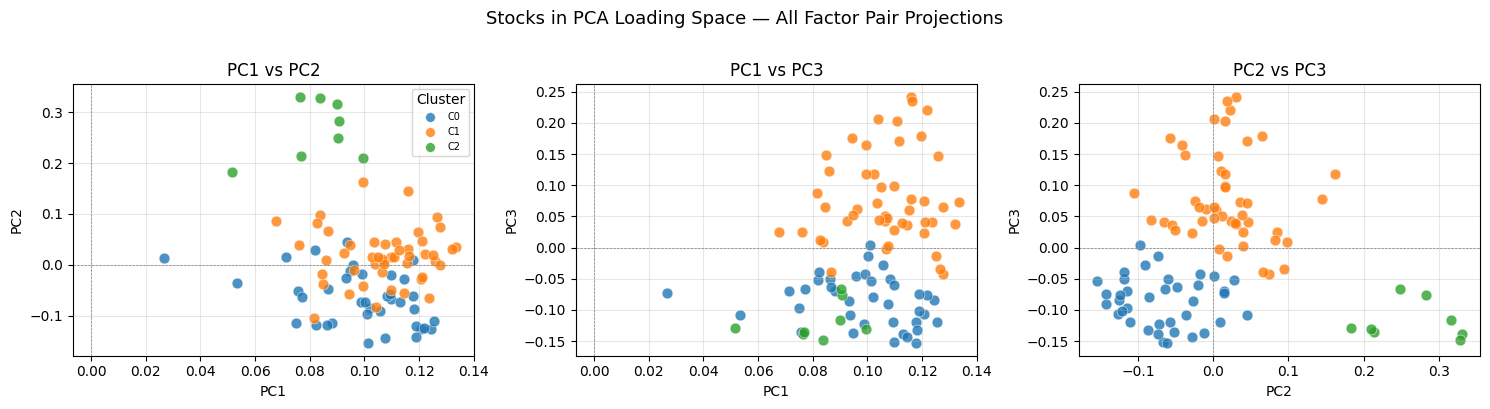

In [35]:
from itertools import combinations

factor_cols = [f'PC{i+1}' for i in range(K_PCA)]
pairs = list(combinations(factor_cols, 2))   # C(K_PCA, 2) pairs

n_pairs = len(pairs)
ncols = 3
nrows = int(np.ceil(n_pairs / ncols))

palette = sns.color_palette('tab10', K_CLUST)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, (fx, fy) in enumerate(pairs):
    ax = axes[idx]
    for c in range(K_CLUST):
        mask = loadings_df['cluster'] == c
        ax.scatter(
            loadings_df.loc[mask, fx],
            loadings_df.loc[mask, fy],
            color=palette[c],
            label=f'C{c}',
            alpha=0.8,
            edgecolors='white',
            linewidths=0.4,
            s=60
        )
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(title='Cluster', fontsize=7, markerscale=0.9)

# Remove unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Stocks in PCA Loading Space — All Factor Pair Projections', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [36]:
# Build sector/industry lookup from yfinance
records = []
for tic in tickers:
    try:
        info = yf.Ticker(tic).info
        records.append({
            'tic':      tic,
            'sector':   info.get('sector',   'Unknown'),
            'industry': info.get('industry', 'Unknown')
        })
    except:
        records.append({'tic': tic, 'sector': 'Unknown', 'industry': 'Unknown'})

sector_df = pd.DataFrame(records).set_index('tic')

# Merge with cluster labels
cluster_sector = loadings_df[['cluster']].copy()
cluster_sector = cluster_sector.join(sector_df)
cluster_sector = cluster_sector.reset_index().rename(columns={'index': 'tic'})

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


In [37]:
cluster_sector

,tic,cluster,sector,industry
0,AAON,1,Industrials,Building Products & Equipment
1,AAPL,0,Technology,Consumer Electronics
2,ADBE,0,Technology,Software - Application
3,ADI,0,Technology,Semiconductors
4,ADP,1,Technology,Software - Application
5,AEP,2,Utilities,Utilities - Regulated Electric
6,AMAT,0,Technology,Semiconductor Equipment & Materials
7,AMD,0,Technology,Semiconductors
8,AMGN,0,Healthcare,Drug Manufacturers - General
9,APA,1,Energy,Oil & Gas E&P


In [38]:
pd.crosstab(cluster_sector['cluster'], cluster_sector['sector'])

sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Unknown,Utilities
cluster,,,,,,,,,,,,
0,1,3,0,0,0,0,7,0,0,27,0,0
1,0,0,8,2,1,12,1,13,2,6,3,0
2,0,0,0,3,0,0,0,0,0,0,0,5


In [39]:
pd.crosstab(cluster_sector['cluster'], cluster_sector['industry'])

industry,Asset Management,Auto Parts,Banks - Regional,Beverages - Non-Alcoholic,Biotechnology,Building Products & Equipment,Capital Markets,Communication Equipment,Computer Hardware,Conglomerates,Consumer Electronics,Credit Services,Diagnostics & Research,Drug Manufacturers - General,Electronic Components,Electronic Gaming & Multimedia,Electronics & Computer Distribution,Engineering & Construction,Farm & Heavy Construction Machinery,Gambling,Gold,Household & Personal Products,Industrial Distribution,Insurance - Property & Casualty,Integrated Freight & Logistics,Internet Content & Information,Leisure,Medical Instruments & Supplies,Oil & Gas E&P,Packaged Foods,REIT - Hotel & Motel,REIT - Retail,Railroads,Rental & Leasing Services,Restaurants,Scientific & Technical Instruments,Semiconductor Equipment & Materials,Semiconductors,Software - Application,Software - Infrastructure,Specialty Business Services,Specialty Industrial Machinery,Specialty Retail,Telecom Services,Trucking,Unknown,Utilities - Regulated Electric
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,1,0,0,2,1,0,1,0,1,2,1,1,0,0,0,0,1,0,0,0,0,1,0,3,0,0,0,0,0,0,0,1,4,10,4,3,0,0,0,1,0,0,0
1,3,2,6,1,0,1,1,0,0,1,0,1,0,0,1,0,1,1,1,1,0,1,1,1,2,0,2,1,1,0,1,1,1,1,2,1,0,0,3,0,1,2,1,0,1,3,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5


In [40]:
industry_cluster_counts = (
    cluster_sector
    .groupby('industry')['cluster']
    .nunique()
    .rename('n_clusters')
)

total_industries     = len(industry_cluster_counts)
exclusive_industries = (industry_cluster_counts == 1).sum()
split_industries     = (industry_cluster_counts > 1).sum()

print(f"Total distinct industries : {total_industries}")
print(f"Exclusively in 1 cluster  : {exclusive_industries}  ({exclusive_industries/total_industries:.1%})")
print(f"Split across >1 cluster   : {split_industries}  ({split_industries/total_industries:.1%})")

print("\nSplit industries:")
split = cluster_sector[cluster_sector['industry'].isin(
    industry_cluster_counts[industry_cluster_counts > 1].index
)]
print(split.groupby('industry')['cluster'].apply(lambda x: sorted(x.unique())).to_string())

Total distinct industries : 47
Exclusively in 1 cluster  : 41  (87.2%)
Split across >1 cluster   : 6  (12.8%)

Split industries:
industry
Beverages - Non-Alcoholic             [1, 2]
Electronic Components                 [0, 1]
Household & Personal Products         [1, 2]
Medical Instruments & Supplies        [0, 1]
Scientific & Technical Instruments    [0, 1]
Software - Application                [0, 1]


In [41]:
# Panel 1 — Seed stability
from sklearn.metrics import adjusted_rand_score

base_labels = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(loadings_df[['PC1','PC2','PC3']].values)

for seed in [0, 123, 7]:
    labels_s = KMeans(n_clusters=3, random_state=seed, n_init=20).fit_predict(loadings_df[['PC1','PC2','PC3']].values)
    ari = adjusted_rand_score(base_labels, labels_s)
    print(f"Seed {seed}  ARI vs seed 42: {ari:.3f}")

# Panel 2 — Holdout period stability
X_test_scaled = scaler.transform(ret_test)
scores_test  = pca.transform(X_test_scaled)   # project test returns through train PCA
loadings_test_df = pd.DataFrame(scores_test, columns=[f'PC{i+1}' for i in range(K_PCA)])

# Fit fresh K-means on test loadings
km_test = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_test = km_test.fit_predict(loadings_test_df.values)

# Compare: use train centroids to assign test stocks, then compare to fresh fit
labels_test_assigned = km_final.predict(scores_test)
ari_holdout = adjusted_rand_score(labels_test, labels_test_assigned)
print(f"Train-centroid vs fresh-fit ARI on test period: {ari_holdout:.3f}")


Seed 0  ARI vs seed 42: 1.000
Seed 123  ARI vs seed 42: 1.000
Seed 7  ARI vs seed 42: 1.000
Train-centroid vs fresh-fit ARI on test period: 0.032


In [42]:
# Fit PCA on test returns using same K
pca_test = PCA(n_components=K_PCA)
pca_test.fit(X_test_scaled)

loadings_test = pca_test.components_.T  # (94, 3) — one row per stock
labels_test_via_centroids = km_final.predict(loadings_test)

test_cluster_df = pd.DataFrame({
    'tic':           ret_test.columns.tolist(),
    'cluster_train': cluster_labels,
    'cluster_test':  labels_test_via_centroids
})

switched = test_cluster_df[test_cluster_df['cluster_train'] != test_cluster_df['cluster_test']]
print(f"Stocks that switched cluster: {len(switched)} of {len(test_cluster_df)}")
print(switched[['tic','cluster_train','cluster_test']].to_string())

Stocks that switched cluster: 13 of 94
     tic  cluster_train  cluster_test
4    ADP              1             0
20  CHTR              0             1
28  CTAS              1             0
32  FAST              1             0
35   GEN              0             1
60  MTCH              0             1
61    MU              0             1
69  PAYX              1             0
77   ROP              1             0
78  SBUX              1             0
86  TTEK              1             0
89   WDC              0             1
93  ZBRA              0             1
